# Phase 3 — Vendor Performance: Data Loading & KPI Engineering

Goal:
1. Connect to SQL Server from Python
2. Pull dbo.VendorSummary into a pandas DataFrame
3. Clean the data (NULLs, whitespace, types)
4. Engineer KPI columns

In [1]:
%pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse
print("Pandas version:", pd.__version__)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_style("whitegrid")

Pandas version: 2.3.3


In [3]:
%pip install pyodbc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
Server = 'DESKTOP-ASPE07O'
Database = 'Vendor'

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={Server};DATABASE={Database};Trusted_Connection=yes;"

)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
try:
    with engine.connect() as connection:
        print("Connection to the database was successful.")
except Exception as e:
    print(f"Error connecting to the database: {e}")

Connection to the database was successful.


In [5]:
query = "SELECT * FROM dbo.VendorSummary"
df = pd.read_sql(query, engine)

print("Shape:", df.shape)
df.head()

Shape: (12261, 18)


,Brand,Description,VendorNumber,VendorName,RetailPrice,ListedPurchasePrice,Classification,TotalPurchaseQunatity,TotalPurchaseDollars,AveragePurchasePrice,TotalSalesQuantity,TotalSalesDollars,TotalExciseTax,TotalFreightcost,BegInventoryQty,BegInventoryValue,EndInventoryQty,EndInventoryValue
0,17759,Joseph Mellot Reuilly Svgn B,653,STATE WINE & SPIRITS,15.990000,11.03,2,1.0,11.030000,11.03,1.0,15.990000,0.110000,8014.980002,NaN,NaN,NaN,NaN
1,20567,The Immortal Zin,653,STATE WINE & SPIRITS,11.990000,7.79,2,42.0,327.180012,7.79,42.0,503.580017,4.740000,8014.980002,NaN,NaN,NaN,NaN
2,3362,Poland Spring Gin,9552,M S WALKER INC,5.990000,4.47,1,5617.0,25107.989722,4.47,5652.0,33855.479071,5934.599974,55551.819733,426.0,2551.739902,391.0,2342.089911
3,24175,Stella Moscato,2000,SOUTHERN WINE & SPIRITS NE,13.990000,9.08,2,10.0,90.800003,9.08,10.0,139.899994,1.120000,19016.589985,NaN,NaN,NaN,NaN
4,45710,Ferrari-Carano Terre Chard,2000,SOUTHERN WINE & SPIRITS NE,35.990002,24.82,2,21.0,521.219994,24.82,21.0,638.790010,2.360000,19016.589985,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12261 entries, 0 to 12260
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Brand                  12261 non-null  int64  
 1   Description            12260 non-null  object 
 2   VendorNumber           12261 non-null  int64  
 3   VendorName             12261 non-null  object 
 4   RetailPrice            12261 non-null  float64
 5   ListedPurchasePrice    12261 non-null  float64
 6   Classification         12261 non-null  int64  
 7   TotalPurchaseQunatity  10649 non-null  float64
 8   TotalPurchaseDollars   10649 non-null  float64
 9   AveragePurchasePrice   10649 non-null  float64
 10  TotalSalesQuantity     11225 non-null  float64
 11  TotalSalesDollars      11225 non-null  float64
 12  TotalExciseTax         11225 non-null  float64
 13  TotalFreightcost       12255 non-null  float64
 14  BegInventoryQty        8094 non-null   float64
 15  Be

In [7]:
df.isnull().sum()

Brand                       0
Description                 1
VendorNumber                0
VendorName                  0
RetailPrice                 0
ListedPurchasePrice         0
Classification              0
TotalPurchaseQunatity    1612
TotalPurchaseDollars     1612
AveragePurchasePrice     1612
TotalSalesQuantity       1036
TotalSalesDollars        1036
TotalExciseTax           1036
TotalFreightcost            6
BegInventoryQty          4167
BegInventoryValue        4167
EndInventoryQty          2608
EndInventoryValue        2608
dtype: int64

In [8]:
df['VendorName'] = df['VendorName'].str.strip()
df['Description'] = df['Description'].str.strip()

In [9]:
fill_zero_cols = [
    'TotalPurchaseQunatity','TotalPurchaseDollars','AveragePurchasePrice',
    'TotalSalesQuantity','TotalSalesDollars','TotalExciseTax','TotalFreightcost','BegInventoryQty','BegInventoryValue',
    'EndInventoryQty','EndInventoryValue'
]
df[fill_zero_cols] = df[fill_zero_cols].fillna(0)
df.isnull().sum()

Brand                    0
Description              1
VendorNumber             0
VendorName               0
RetailPrice              0
ListedPurchasePrice      0
Classification           0
TotalPurchaseQunatity    0
TotalPurchaseDollars     0
AveragePurchasePrice     0
TotalSalesQuantity       0
TotalSalesDollars        0
TotalExciseTax           0
TotalFreightcost         0
BegInventoryQty          0
BegInventoryValue        0
EndInventoryQty          0
EndInventoryValue        0
dtype: int64

In [10]:
df['Description'] = df['Description'].fillna('Unknown')

In [11]:
df.isnull().sum()

Brand                    0
Description              0
VendorNumber             0
VendorName               0
RetailPrice              0
ListedPurchasePrice      0
Classification           0
TotalPurchaseQunatity    0
TotalPurchaseDollars     0
AveragePurchasePrice     0
TotalSalesQuantity       0
TotalSalesDollars        0
TotalExciseTax           0
TotalFreightcost         0
BegInventoryQty          0
BegInventoryValue        0
EndInventoryQty          0
EndInventoryValue        0
dtype: int64

In [12]:
import numpy as np

In [13]:
# Gross Profit: actual revenue minus actual cost paid
df['GrossProfit'] = df['TotalSalesDollars'] - df['TotalPurchaseDollars']

# Profit Margin %: guard against division by zero (no sales -> undefined margin, not 0)
df['ProfitMargin'] = np.where(
    df['TotalSalesDollars'] > 0,
    (df['GrossProfit'] / df['TotalSalesDollars']) * 100,
    np.nan
)

# Stock Turnover: sales qty / average inventory
df['AvgInventory'] = (df['BegInventoryQty'] + df['EndInventoryQty']) / 2
df['StockTurnover'] = np.where(
    df['AvgInventory'] > 0,
    df['TotalSalesQuantity'] / df['AvgInventory'],
    np.nan
)

# Sales-to-Purchase Ratio: how many $ sold per $ spent buying
df['SalesToPurchaseRatio'] = np.where(
    df['TotalPurchaseDollars'] > 0,
    df['TotalSalesDollars'] / df['TotalPurchaseDollars'],
    np.nan
)

# Freight Cost %: freight as a share of what we spent buying from that vendor
df['FreightCostPct'] = np.where(
    df['TotalPurchaseDollars'] > 0,
    (df['TotalFreightcost'] / df['TotalPurchaseDollars']) * 100,
    np.nan
)

df[['Brand','VendorName','GrossProfit','ProfitMargin','StockTurnover','SalesToPurchaseRatio','FreightCostPct']].head(10)

,Brand,VendorName,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,FreightCostPct
0,17759,STATE WINE & SPIRITS,4.960000,31.019388,NaN,1.449683,72665.278293
1,20567,STATE WINE & SPIRITS,176.400005,35.029191,NaN,1.539153,2449.715665
2,3362,M S WALKER INC,8747.489349,25.837736,13.835985,1.348395,221.251563
3,24175,SOUTHERN WINE & SPIRITS NE,49.099991,35.096492,NaN,1.540749,20943.380337
4,45710,SOUTHERN WINE & SPIRITS NE,117.570017,18.405112,NaN,1.225567,3648.476693
5,17266,SOUTHERN WINE & SPIRITS NE,23.109995,9.635990,1.172414,1.106635,8774.727703
6,4355,SEA HAGG DISTILLERY LLC,4560.749943,48.939076,3.530516,1.958445,19.660018
7,4362,M S WALKER INC,13588.570371,25.072935,21.363780,1.334631,136.801535
8,16555,SOUTHERN WINE & SPIRITS NE,3944.209747,36.566609,3.843003,1.576457,277.932546
9,1215,SOUTHERN WINE & SPIRITS NE,3357.149883,95.660016,0.389892,23.041559,12485.450603


In [14]:
df[['GrossProfit','ProfitMargin','StockTurnover','SalesToPurchaseRatio','FreightCostPct']].describe()

,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,FreightCostPct
count,1.226100e+04,11225.000000,10662.000000,10648.000000,1.064800e+04
mean,1.060028e+04,-7.976720,18.929182,2.501247,2.300397e+04
std,4.334896e+04,433.784530,506.064239,8.436409,2.516367e+05
min,-5.200278e+04,-23730.639302,0.000000,0.000000,4.568383e-01
25%,8.069992e+00,18.060663,1.789474,1.155445,1.430019e+02
50%,7.384900e+02,31.873377,3.287290,1.437604,7.853809e+02
75%,6.683060e+03,44.940571,6.611751,1.665539,5.958416e+03
max,1.290668e+06,100.000000,48649.000000,352.928581,1.748517e+07


In [15]:
# To See the negative profit margin outliers.

df.sort_values('ProfitMargin').head(10)[['Brand','VendorName','TotalSalesDollars','TotalPurchaseDollars','GrossProfit','ProfitMargin']]

,Brand,VendorName,TotalSalesDollars,TotalPurchaseDollars,GrossProfit,ProfitMargin
5461,27342,TREASURY WINE ESTATES,38.969999,9286.799973,-9247.829973,-23730.639302
11209,15880,SOUTHERN WINE & SPIRITS NE,149.979996,29213.999878,-29064.019882,-19378.597620
6362,27553,MARTIGNETTI COMPANIES,26.990000,4049.279907,-4022.289907,-14902.889743
10110,27274,ULTRA BEVERAGE COMPANY LLP,209.990005,23881.500000,-23671.509995,-11272.684116
27,27969,SOUTHERN GLAZERS W&S OF NE,36.990002,4089.119812,-4052.129810,-10954.662413
1294,22591,VINILANDIA USA,15.990000,1535.919975,-1519.929976,-9505.503423
6453,2094,M S WALKER INC,133.979996,11149.200073,-11015.220078,-8221.540848
4079,13557,MARTIGNETTI COMPANIES,69.989998,5525.999756,-5456.009758,-7795.413523
1854,15901,MARTIGNETTI COMPANIES,79.989998,5960.399780,-5880.409782,-7351.431353
5090,26266,SOUTHERN WINE & SPIRITS NE,33.980000,1525.920013,-1491.940014,-4390.641654


In [16]:
# Extreme StockTurnover outliers.
df.sort_values('StockTurnover', ascending=False).head(10)[['Brand','VendorName','TotalSalesQuantity','AvgInventory','StockTurnover']]

,Brand,VendorName,TotalSalesQuantity,AvgInventory,StockTurnover
10152,3265,SAZERAC CO INC,48649.0,1.0,48649.000000
4305,2327,DIAGEO NORTH AMERICA INC,5494.0,0.5,10988.000000
5128,1085,DIAGEO NORTH AMERICA INC,3839.0,0.5,7678.000000
5121,1383,DIAGEO NORTH AMERICA INC,6766.0,1.0,6766.000000
11992,25519,CONSTELLATION BRANDS INC,2375.0,0.5,4750.000000
280,25710,E & J GALLO WINERY,2272.0,0.5,4544.000000
444,4260,DIAGEO NORTH AMERICA INC,79042.0,19.0,4160.105263
411,25588,SOUTHERN WINE & SPIRITS NE,3957.0,1.0,3957.000000
6952,27103,E & J GALLO WINERY,3663.0,1.0,3663.000000
5940,10991,M S WALKER INC,1469.0,0.5,2938.000000


In [17]:
#Fix FreightCostPct: recalculate at Vendor grain, not Brand grain

vendor_level = df.groupby('VendorNumber').agg(
    VendorTotalPurchaseDollars=('TotalPurchaseDollars','sum'),
    VendorTotalFreight=('TotalFreightcost','first')  # freight is already the same value repeated per brand for a vendor
).reset_index()

vendor_level['VendorFreightCostPct'] = np.where(
    vendor_level['VendorTotalPurchaseDollars'] > 0,
    (vendor_level['VendorTotalFreight'] / vendor_level['VendorTotalPurchaseDollars']) * 100,
    np.nan
)

vendor_level.sort_values('VendorFreightCostPct', ascending=False).head(10)

,VendorNumber,VendorTotalPurchaseDollars,VendorTotalFreight,VendorFreightCostPct
64,6830,5.672462e+04,360.290001,0.635156
57,5992,2.872885e+05,1567.849998,0.545741
72,8004,9.226706e+06,50293.619843,0.545088
107,28776,4.844558e+04,259.900001,0.536478
89,9625,3.612492e+05,1933.190010,0.535140
42,3951,5.500320e+03,29.430000,0.535060
3,105,1.170620e+04,62.389999,0.532965
21,1590,1.365473e+06,7259.750034,0.531666
118,90046,3.658801e+04,194.129999,0.530584
114,90032,1.468395e+05,778.250003,0.530000


In [18]:
#Merging the vendor-level freight cost percentage back into the main dataframe and replacing the brand-level values.
df = df.merge(vendor_level[['VendorNumber','VendorFreightCostPct']], on='VendorNumber', how='left')
df.drop(columns=['FreightCostPct'], inplace=True)
df.rename(columns={'VendorFreightCostPct':'FreightCostPct'}, inplace=True)

In [19]:
# Flag brands where Sales or Inventory base is too small to trust ratio-based KPIs
df['LowSalesVolumeFlag'] = df['TotalSalesDollars'] < 500        # threshold: adjust later if needed
df['LowInventoryBaseFlag'] = df['AvgInventory'] < 2              # near-zero inventory denominator

print("Low sales volume brands:", df['LowSalesVolumeFlag'].sum())
print("Low inventory base brands:", df['LowInventoryBaseFlag'].sum())

Low sales volume brands: 3635
Low inventory base brands: 1983


In [20]:
#Combined Reliability Flag: True if both sales and inventory are sufficient to trust ratio-based KPIs
df['ReliableForRatioAnalysis'] = (~df['LowSalesVolumeFlag']) & (~df['LowInventoryBaseFlag'])

print("Reliable for ratio analysis:", df['ReliableForRatioAnalysis'].sum())
print("Flagged (exclude from ratio ranking, keep in totals):", (~df['ReliableForRatioAnalysis']).sum())

Reliable for ratio analysis: 8265
Flagged (exclude from ratio ranking, keep in totals): 3996


In [21]:
#Phase 3 er final output: cleaned+enriched table SQL Server e save koro (Power BI ei table theke direct pore nebe, raw view na
df.to_sql('VendorSummaryFinal', con=engine, if_exists='replace', index=False)
print("✅ Saved VendorSummaryFinal to SQL Server")

✅ Saved VendorSummaryFinal to SQL Server


In [22]:
#local backup CSV
df.to_csv('vendor_summary_final.csv', index=False)
print("✅ Saved local CSV backup, shape:", df.shape)

✅ Saved local CSV backup, shape: (12261, 27)


Profit Margin Distribution

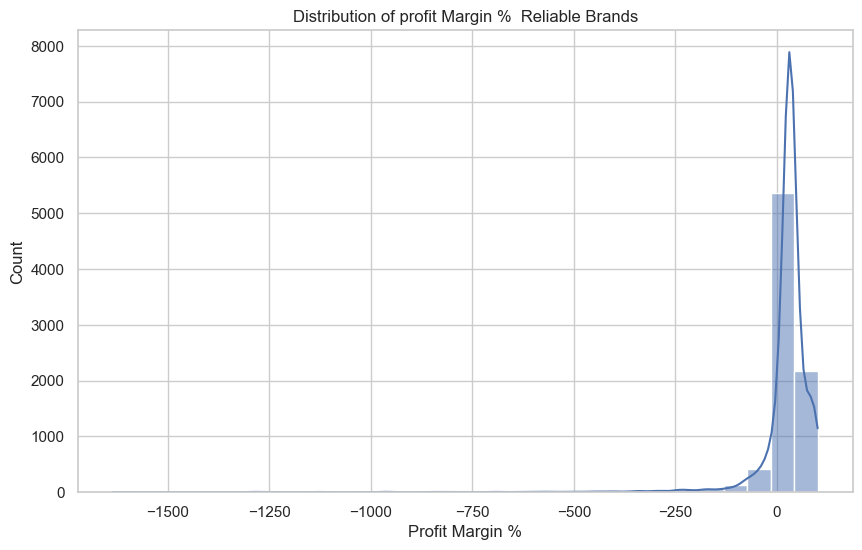

       ProfitMargin
count   8265.000000
mean      23.355389
std       80.854878
min    -1634.249217
25%       21.368664
50%       31.930617
75%       43.201240
max      100.000000


In [25]:
reliable_df = df[df['ReliableForRatioAnalysis']]

plt.figure(figsize=(10, 6))
sns.histplot(reliable_df['ProfitMargin'].dropna(), bins=30, kde=True)
plt.title('Distribution of profit Margin %  Reliable Brands')
plt.xlabel('Profit Margin %')
plt.show()

print(reliable_df[['ProfitMargin']].describe())

In [26]:
vendor_profit = df.groupby('VendorName').agg(
    TotalGrossProfit=('GrossProfit','sum'),
    TotalSalesDollars=('TotalSalesDollars','sum'),
    AvgProfitMargin=('ProfitMargin','mean')
).reset_index().sort_values('TotalGrossProfit', ascending=False)

print("TOP 10 VENDORS:")
print(vendor_profit.head(10))

print("\nBOTTOM 10 VENDORS:")
print(vendor_profit.tail(10))

TOP 10 VENDORS:
                     VendorName  TotalGrossProfit  TotalSalesDollars  \
29     DIAGEO NORTH AMERICA INC      1.778262e+07       6.874242e+07   
66        MARTIGNETTI COMPANIES      1.319228e+07       4.104117e+07   
24     CONSTELLATION BRANDS INC      8.895255e+06       2.446917e+07   
78            PERNOD RICARD USA      8.157156e+06       3.228125e+07   
53      JIM BEAM BRANDS COMPANY      7.703169e+06       3.190632e+07   
8               BACARDI USA INC      7.390178e+06       2.501456e+07   
34           E & J GALLO WINERY      6.266477e+06       1.855609e+07   
15            BROWN-FORMAN CORP      4.949124e+06       1.847856e+07   
118  ULTRA BEVERAGE COMPANY LLP      4.645585e+06       1.774243e+07   
62               M S WALKER INC      4.517417e+06       1.543500e+07   

     AvgProfitMargin  
29         26.182581  
66        -25.125274  
24         11.732066  
78         28.416796  
53         24.533989  
8          36.289471  
34         13.232083  
15     

Corrected vendor-level margin (dollar-weighted, not simple average):

In [27]:
vendor_summary = df.groupby('VendorName').agg(
    TotalGrossProfit=('GrossProfit','sum'),
    TotalSalesDollars=('TotalSalesDollars','sum'),
    TotalPurchaseDollars=('TotalPurchaseDollars','sum')
).reset_index()

# TRUE overall margin: sum of profit / sum of sales (dollar-weighted, not avg of %)
vendor_summary['OverallMarginPct'] = (
    vendor_summary['TotalGrossProfit'] / vendor_summary['TotalSalesDollars']
) * 100

vendor_summary = vendor_summary.sort_values('TotalGrossProfit', ascending=False)

print("TOP 10 VENDORS (corrected margin):")
print(vendor_summary.head(10)[['VendorName','TotalGrossProfit','TotalSalesDollars','OverallMarginPct']])

print("\nBOTTOM 10 VENDORS (corrected margin):")
print(vendor_summary.tail(10)[['VendorName','TotalGrossProfit','TotalSalesDollars','OverallMarginPct']])

TOP 10 VENDORS (corrected margin):
                     VendorName  TotalGrossProfit  TotalSalesDollars  \
29     DIAGEO NORTH AMERICA INC      1.778262e+07       6.874242e+07   
66        MARTIGNETTI COMPANIES      1.319228e+07       4.104117e+07   
24     CONSTELLATION BRANDS INC      8.895255e+06       2.446917e+07   
78            PERNOD RICARD USA      8.157156e+06       3.228125e+07   
53      JIM BEAM BRANDS COMPANY      7.703169e+06       3.190632e+07   
8               BACARDI USA INC      7.390178e+06       2.501456e+07   
34           E & J GALLO WINERY      6.266477e+06       1.855609e+07   
15            BROWN-FORMAN CORP      4.949124e+06       1.847856e+07   
118  ULTRA BEVERAGE COMPANY LLP      4.645585e+06       1.774243e+07   
62               M S WALKER INC      4.517417e+06       1.543500e+07   

     OverallMarginPct  
29          25.868483  
66          32.144005  
24          36.352904  
78          25.269024  
53          24.143083  
8           29.543510  
34  

In [28]:
# Vendor-level total sales (using our corrected vendor_summary)
median_sales = vendor_summary['TotalSalesDollars'].median()

high_sales_vendors = vendor_summary[vendor_summary['TotalSalesDollars'] >= median_sales]['VendorName']
low_sales_vendors = vendor_summary[vendor_summary['TotalSalesDollars'] < median_sales]['VendorName']

print("High-sales vendors:", len(high_sales_vendors))
print("Low-sales vendors:", len(low_sales_vendors))

High-sales vendors: 67
Low-sales vendors: 66


In [29]:
#Brand-level margin (reliable only)
high_group = reliable_df[reliable_df['VendorName'].isin(high_sales_vendors)]['ProfitMargin'].dropna()
low_group = reliable_df[reliable_df['VendorName'].isin(low_sales_vendors)]['ProfitMargin'].dropna()

print("High-sales group: n =", len(high_group), ", mean margin =", high_group.mean().round(2))
print("Low-sales group: n =", len(low_group), ", mean margin =", low_group.mean().round(2))

High-sales group: n = 7985 , mean margin = 23.46
Low-sales group: n = 280 , mean margin = 20.48


In [30]:
#Independent t-test (statistically significant difference kina check)
t_stat, p_value = stats.ttest_ind(high_group, low_group, equal_var=False)  # Welch's t-test (unequal variance safe)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Statistically significant difference (p < 0.05)")
else:
    print("❌ No statistically significant difference (p >= 0.05)")

T-statistic: 0.6454
P-value: 0.519129
❌ No statistically significant difference (p >= 0.05)


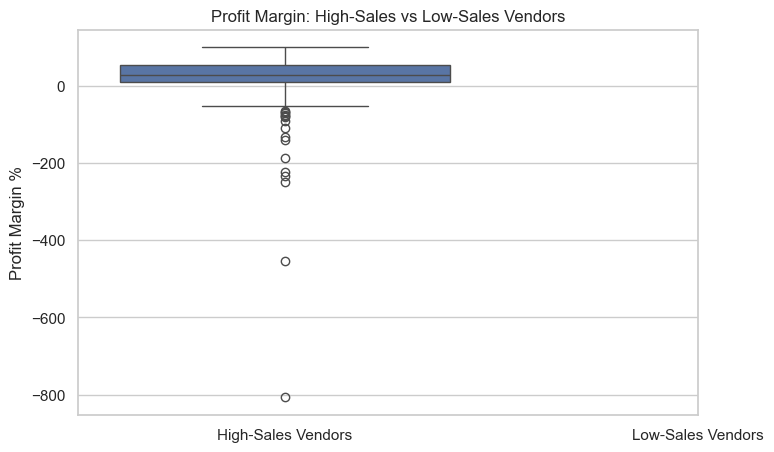

In [31]:
#Visualize the comparison
plt.figure(figsize=(8,5))
sns.boxplot(data=[high_group, low_group])
plt.xticks([0,1], ['High-Sales Vendors', 'Low-Sales Vendors'])
plt.ylabel('Profit Margin %')
plt.title('Profit Margin: High-Sales vs Low-Sales Vendors')
plt.show()

In [32]:
# Correct approach Vendor-level comparison (ekta vendor = ekta data point)
high_vendor_margins = vendor_summary[vendor_summary['VendorName'].isin(high_sales_vendors)]['OverallMarginPct']
low_vendor_margins = vendor_summary[vendor_summary['VendorName'].isin(low_sales_vendors)]['OverallMarginPct']

print("High-sales vendors: n =", len(high_vendor_margins), ", mean margin =", high_vendor_margins.mean().round(2))
print("Low-sales vendors: n =", len(low_vendor_margins), ", mean margin =", low_vendor_margins.mean().round(2))

t_stat2, p_value2 = stats.ttest_ind(high_vendor_margins, low_vendor_margins, equal_var=False)
print(f"\nT-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.6f}")

if p_value2 < 0.05:
    print("✅ Statistically significant difference (p < 0.05)")
else:
    print("❌ No statistically significant difference (p >= 0.05)")

High-sales vendors: n = 67 , mean margin = 27.2
Low-sales vendors: n = 66 , mean margin = -inf

T-statistic: nan
P-value: nan
❌ No statistically significant difference (p >= 0.05)


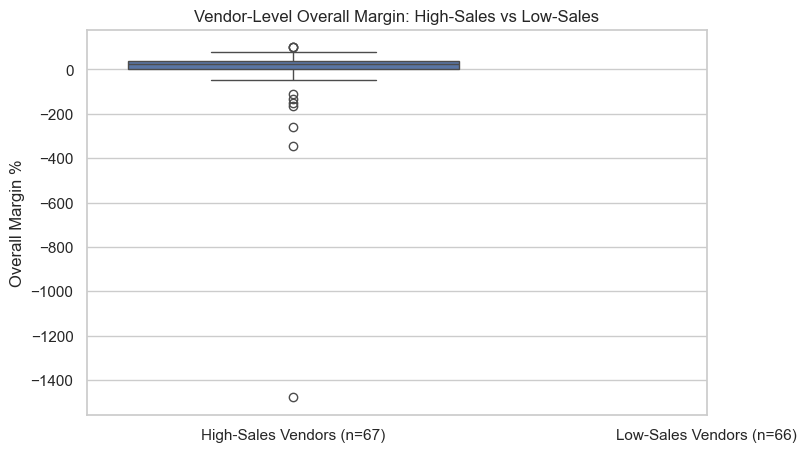

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[high_vendor_margins, low_vendor_margins])
plt.xticks([0,1], ['High-Sales Vendors (n=67)', 'Low-Sales Vendors (n=66)'])
plt.ylabel('Overall Margin %')
plt.title('Vendor-Level Overall Margin: High-Sales vs Low-Sales')
plt.show()

In [34]:
# Find out zero sales vendor first
problem_vendors = vendor_summary[vendor_summary['TotalSalesDollars'] <= 0]
print(problem_vendors[['VendorName','TotalGrossProfit','TotalSalesDollars','OverallMarginPct']])

                     VendorName  TotalGrossProfit  TotalSalesDollars  \
40             FLEMISH LION LLC          0.000000                0.0   
72        Mizkan Americas, Inc.          0.000000                0.0   
45              HALO DISTILLERY          0.000000                0.0   
0   AAPER ALCOHOL & CHEMICAL CO       -105.070000                0.0   
59          LAUREATE IMPORTS CO       -140.940002                0.0   

    OverallMarginPct  
40               NaN  
72               NaN  
45               NaN  
0               -inf  
59              -inf  


In [35]:
# Exclude zero sales vendors and do test again
vendor_summary_clean = vendor_summary[vendor_summary['TotalSalesDollars'] > 0].copy()

high_vendor_margins = vendor_summary_clean[vendor_summary_clean['VendorName'].isin(high_sales_vendors)]['OverallMarginPct']
low_vendor_margins = vendor_summary_clean[vendor_summary_clean['VendorName'].isin(low_sales_vendors)]['OverallMarginPct']

print("High-sales vendors: n =", len(high_vendor_margins), ", mean margin =", high_vendor_margins.mean().round(2))
print("Low-sales vendors: n =", len(low_vendor_margins), ", mean margin =", low_vendor_margins.mean().round(2))

t_stat2, p_value2 = stats.ttest_ind(high_vendor_margins, low_vendor_margins, equal_var=False)
print(f"\nT-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.6f}")

if p_value2 < 0.05:
    print("✅ Statistically significant difference (p < 0.05)")
else:
    print("❌ No statistically significant difference (p >= 0.05)")

High-sales vendors: n = 67 , mean margin = 27.2
Low-sales vendors: n = 61 , mean margin = -17.72

T-statistic: 1.7075
P-value: 0.092877
❌ No statistically significant difference (p >= 0.05)


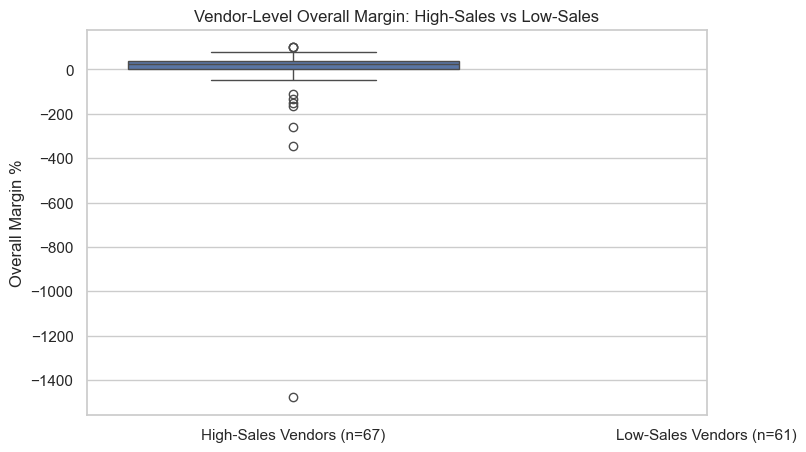

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[high_vendor_margins, low_vendor_margins])
plt.xticks([0,1], [f'High-Sales Vendors (n={len(high_vendor_margins)})', f'Low-Sales Vendors (n={len(low_vendor_margins)})'])
plt.ylabel('Overall Margin %')
plt.title('Vendor-Level Overall Margin: High-Sales vs Low-Sales')
plt.show()

In [37]:
# Mann-Whitney U test (non-parametric alternative to t-test)
u_stat, p_value_mw = stats.mannwhitneyu(high_vendor_margins, low_vendor_margins, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat:.4f}")
print(f"P-value: {p_value_mw:.6f}")

if p_value_mw < 0.05:
    print("✅ Statistically significant difference (p < 0.05)")
else:
    print("❌ No statistically significant difference (p >= 0.05)")

Mann-Whitney U statistic: 2388.0000
P-value: 0.100761
❌ No statistically significant difference (p >= 0.05)


In [38]:
#Median comparison (outlier-resistant central tendency)
print("High-sales vendors median margin:", high_vendor_margins.median().round(2))
print("Low-sales vendors median margin:", low_vendor_margins.median().round(2))

High-sales vendors median margin: 27.38
Low-sales vendors median margin: 23.56


In [39]:
extreme_low = vendor_summary_clean[
    (vendor_summary_clean['VendorName'].isin(low_sales_vendors)) &
    (vendor_summary_clean['OverallMarginPct'] < -100)
]
print(extreme_low[['VendorName','TotalGrossProfit','TotalSalesDollars','OverallMarginPct']])

                        VendorName  TotalGrossProfit  TotalSalesDollars  \
116                   TRUETT HURST       -221.650000          14.990000   
60                LOYAL DOG WINERY      -1209.540030        1111.259989   
119                       UNCORKED      -1841.930019        1124.379993   
48     HIGHLAND WINE MERCHANTS LLC      -3966.639946        1533.680023   
51   IRA GOLDMAN AND WILLIAMS, LLP      -4365.299988        1265.580017   
123            VINEYARD BRANDS LLC      -6627.549915        4323.960155   
11            BLACK COVE BEVERAGES      -8208.190317        6256.869978   

     OverallMarginPct  
116      -1478.652455  
60        -108.844019  
119       -163.817395  
48        -258.635432  
51        -344.924851  
123       -153.275000  
11        -131.186845  


Correlation between Freight Cost % and Margin %: -0.079


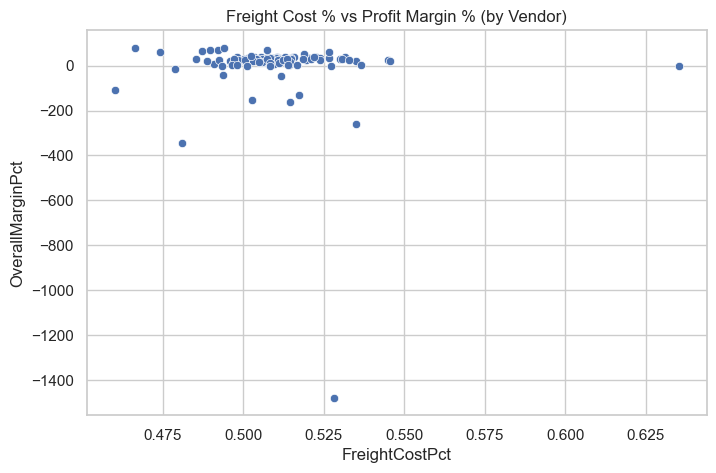

In [41]:
#Freight vs Margin correlation
corr_data = vendor_summary_clean.merge(
    df.groupby('VendorName')['FreightCostPct'].mean().reset_index(),
    on='VendorName'
)

correlation = corr_data['FreightCostPct'].corr(corr_data['OverallMarginPct'])
print("Correlation between Freight Cost % and Margin %:", round(correlation, 3))

plt.figure(figsize=(8,5))
sns.scatterplot(data=corr_data, x='FreightCostPct', y='OverallMarginPct')
plt.title('Freight Cost % vs Profit Margin % (by Vendor)')
plt.show()